# 🇮🇳 Hindi NLP Ambiguity Resolution using Transformer (mBERT)
## Assignment: Ambiguity in NLP — Hindi Language

This notebook demonstrates:
- **Lexical, Syntactic, and Semantic ambiguity** in Hindi
- Fine-tuning **mBERT** (bert-base-multilingual-cased) for 3-class classification
- Training curves, confusion matrix, attention visualisation, and inference

> **Run all cells top-to-bottom. First time will download the mBERT model (~700 MB).**


In [1]:
!pip install transformers datasets torch scikit-learn seaborn matplotlib -q


In [2]:
# ============================================================
#  Hindi NLP Ambiguity Resolution using Transformer (BERT)
#  Assignment: NLP - Ambiguity in Hindi Language
#  Paste this ENTIRE file into a Google Colab notebook (.ipynb)
#  or run cell-by-cell after copying into Colab cells.
# ============================================================

In [3]:
# !pip install transformers datasets torch scikit-learn seaborn matplotlib
# (Uncomment the line above when running in Colab)

In [7]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from torch.optim import AdamW # Corrected import path for AdamW
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
import warnings, random, os

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

print("✅ All libraries imported successfully!")
print(f"   PyTorch version : {torch.__version__}")
print(f"   CUDA available  : {torch.cuda.is_available()}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"   Using device    : {DEVICE}")


# ────────────────────────────────────────────────────────────
# CELL 3 : Dataset — Hindi Ambiguous Sentences
#           Each sentence has a label denoting the correct
#           SENSE of the ambiguous word/phrase.
#           Labels:
#             0 = Lexical ambiguity (word-sense)
#             1 = Syntactic / Structural ambiguity
#             2 = Semantic / Scope ambiguity
# ────────────────────────────────────────────────────────────

HINDI_DATA = [
    # ── Lexical ambiguity (label 0) ─────────────────────────
    # "kala" → black OR art
    ("यह काला रंग है।",                          0),   # This is black colour.
    ("उसे काला सीखना है।",                        0),   # He wants to learn art.
    # "aam" → mango OR common/ordinary
    ("मुझे आम खाना है।",                          0),   # I want to eat mango.
    ("यह एक आम बात है।",                          0),   # This is a common thing.
    # "patta" → leaf OR card/clue
    ("पेड़ से पत्ता गिरा।",                        0),   # A leaf fell from the tree.
    ("उसने पत्ता फेंक दिया।",                      0),   # He threw the card.
    # "sar" → head OR lake/pond
    ("उसका सर दर्द कर रहा है।",                   0),   # His head is aching.
    ("हम सर के पास गए।",                          0),   # We went near the lake.
    # "kaan" → ear OR crow (dialectal)
    ("उसके कान बड़े हैं।",                         0),   # He has big ears.
    ("कान पेड़ पर बैठा है।",                       0),   # The crow is sitting on the tree.
    # "neta" → leader OR vein (archaic)
    ("वह एक अच्छा नेता है।",                       0),   # He is a good leader.
    # "kaal" → time OR death OR yesterday (dialectal)
    ("वह काल के गाल में समा गया।",                 0),   # He perished in the jaws of death.
    ("काल मैं दिल्ली जाऊंगा।",                    0),   # Tomorrow I will go to Delhi.
    # "bail" → ox OR bail (loanword)
    ("बैल खेत में काम कर रहा है।",                 0),   # The ox is working in the field.
    ("उसे जेल से बेल मिल गई।",                    0),   # He got bail from jail.
    # "danda" → stick OR officer (slang)
    ("बच्चे ने डंडा उठाया।",                      0),   # The child picked up a stick.
    ("डंडा आ गया, सब भाग गए।",                    0),   # The officer came, everyone ran.
    # "phal" → fruit OR result/consequence
    ("यह पेड़ अच्छे फल देता है।",                  0),   # This tree gives good fruit.
    ("मेहनत का फल मीठा होता है।",                  0),   # The result of hard work is sweet.
    # ── Syntactic / Structural ambiguity (label 1) ──────────
    # PP attachment: "उसने देखा लाठी लेकर आदमी को"
    # (He saw the man with a stick — who has the stick?)
    ("उसने लाठी लेकर आदमी को देखा।",              1),
    ("राम ने श्याम को मारा जब वह आया।",            1),   # Who came? Ram or Shyam?
    ("वह आदमी जो मेरे घर आया थका हुआ था।",         1),   # Relative clause attachment
    ("लड़की और लड़के ने दौड़ लगाई जो थके हुए थे।",  1),   # Coordination ambiguity
    ("उसने कहा कि वह जाएगा।",                     1),   # Who will go? Nested subject
    ("मेरा दोस्त और उसका भाई आएगा।",               1),   # Number agreement ambiguity
    ("वह लड़की को देखकर मुस्कुराया।",              1),   # Who smiled? Subject ambiguity
    ("मैंने उसे मारते देखा।",                      1),   # Who is hitting whom?
    ("छत पर बैठे आदमी ने गाना गाया।",              1),   # Adjunct attachment
    ("बच्चे और माँ ने मिलकर खाना बनाया।",          1),
    ("उसने चाकू से आदमी को मारा।",                 1),   # Instrument attachment
    ("राम ने सेब खाते हुए गाना सुना।",              1),   # Participle attachment
    ("वह दौड़ता हुआ लड़का स्कूल गया।",              1),
    ("मैं उसे बाज़ार में मिली लड़की से मिला।",       1),
    ("उसने बताया कि कल वह आएगा।",                  1),
    # ── Semantic / Scope ambiguity (label 2) ────────────────
    # Negation scope, quantifier scope
    ("हर छात्र ने कोई किताब नहीं पढ़ी।",            2),   # Every student / no book
    ("कुछ लोग सभी जानवरों से प्यार करते हैं।",      2),   # Some people / all animals
    ("मैं उसे नहीं जानता शायद।",                   2),   # Negation + hedge scope
    ("वह हमेशा झूठ नहीं बोलता।",                   2),   # Always/not scope
    ("सभी बच्चे कोई खेल जानते हैं।",               2),   # All/some quantifier scope
    ("उसने शायद नहीं जाना चाहा।",                  2),   # Modal + negation scope
    ("हर आदमी एक औरत से प्यार करता है।",           2),   # Universal / existential
    ("कम से कम दो छात्र पास नहीं हुए।",             2),   # At-least scope
    ("वह कभी-कभी नहीं आता है।",                    2),   # Frequency + negation
    ("उसे सभी ने नहीं देखा।",                      2),   # Not all / all not
    ("मुझे लगता है कि शायद वह आए।",                2),   # Belief + epistemic scope
    ("वह जल्दी-जल्दी कभी नहीं बोलता।",             2),
    ("राम या श्याम में से कोई एक आएगा।",            2),
    ("मैं हर दिन कुछ न कुछ सीखता हूँ।",            2),
    ("वह न तो खाता है न सोता है।",                  2),
]

# Create DataFrame
df = pd.DataFrame(HINDI_DATA, columns=["sentence", "label"])
label_names = {0: "Lexical", 1: "Syntactic", 2: "Semantic"}
df["label_name"] = df["label"].map(label_names)

print(f"\n📊 Dataset Summary")
print(f"   Total samples : {len(df)}")
print(df["label_name"].value_counts().to_string())
print("\nSample rows:")
print(df.head(6).to_string(index=False))

✅ All libraries imported successfully!
   PyTorch version : 2.10.0+cpu
   CUDA available  : False
   Using device    : cpu

📊 Dataset Summary
   Total samples : 49
label_name
Lexical      19
Syntactic    15
Semantic     15

Sample rows:
             sentence  label label_name
      यह काला रंग है।      0    Lexical
   उसे काला सीखना है।      0    Lexical
     मुझे आम खाना है।      0    Lexical
     यह एक आम बात है।      0    Lexical
  पेड़ से पत्ता गिरा।      0    Lexical
उसने पत्ता फेंक दिया।      0    Lexical


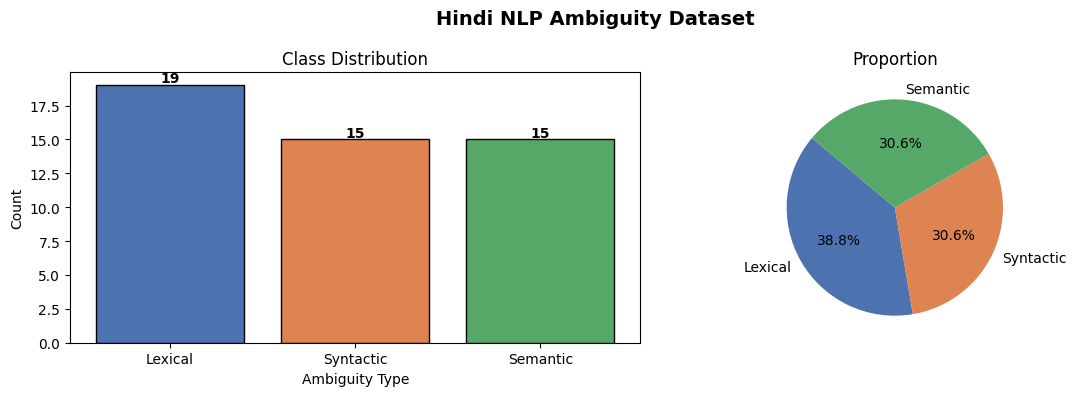

✅ Distribution chart saved.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Hindi NLP Ambiguity Dataset", fontsize=14, fontweight="bold")

counts = df["label_name"].value_counts()
colors = ["#4C72B0", "#DD8452", "#55A868"]

axes[0].bar(counts.index, counts.values, color=colors, edgecolor="black")
axes[0].set_title("Class Distribution")
axes[0].set_xlabel("Ambiguity Type")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 0.2, str(v), ha="center", fontweight="bold")

axes[1].pie(
    counts.values,
    labels=counts.index,
    colors=colors,
    autopct="%1.1f%%",
    startangle=140,
)
axes[1].set_title("Proportion")

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Distribution chart saved.")

In [9]:
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df["label"])
val_df, test_df   = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df["label"])

print(f"Train : {len(train_df)}  |  Val : {len(val_df)}  |  Test : {len(test_df)}")


# ────────────────────────────────────────────────────────────
# CELL 6 : Tokenizer — Multilingual BERT (mBERT)
#           Works for Hindi without a dedicated Hindi BERT
# ────────────────────────────────────────────────────────────
MODEL_NAME  = "bert-base-multilingual-cased"   # mBERT — supports Hindi
MAX_LENGTH  = 128
BATCH_SIZE  = 8
NUM_EPOCHS  = 5
LR          = 2e-5
NUM_LABELS  = 3

print(f"\n⬇️  Loading tokenizer : {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("✅ Tokenizer ready.")

# Quick tokenisation demo
demo = "यह एक आम बात है।"
enc  = tokenizer(demo, return_tensors="pt")
print(f"\nDemo encoding for: '{demo}'")
print(f"  Token IDs : {enc['input_ids'][0].tolist()}")
print(f"  Tokens    : {tokenizer.convert_ids_to_tokens(enc['input_ids'][0])}")

Train : 34  |  Val : 7  |  Test : 8

⬇️  Loading tokenizer : bert-base-multilingual-cased


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Tokenizer ready.

Demo encoding for: 'यह एक आम बात है।'
  Token IDs : [101, 13525, 11186, 70575, 70811, 10569, 920, 102]
  Tokens    : ['[CLS]', 'यह', 'एक', 'आम', 'बात', 'है', '।', '[SEP]']


In [10]:
class HindiAmbiguityDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len=128):
        self.data      = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sentence = str(self.data.loc[idx, "sentence"])
        label    = int(self.data.loc[idx, "label"])
        enc = self.tokenizer(
            sentence,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "label":          torch.tensor(label, dtype=torch.long),
        }


train_dataset = HindiAmbiguityDataset(train_df, tokenizer, MAX_LENGTH)
val_dataset   = HindiAmbiguityDataset(val_df,   tokenizer, MAX_LENGTH)
test_dataset  = HindiAmbiguityDataset(test_df,  tokenizer, MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE)

print(f"✅ DataLoaders ready | Train batches: {len(train_loader)}")

✅ DataLoaders ready | Train batches: 5


In [19]:
print(f"\n⬇️  Loading model : {MODEL_NAME}")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS, attn_implementation="eager"
)
model.to(DEVICE)
print("✅ Model loaded and moved to", DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"   Total params    : {total_params:,}")
print(f"   Trainable params: {trainable_params:,}")


⬇️  Loading model : bert-base-multilingual-cased


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Model loaded and moved to cpu
   Total params    : 177,855,747
   Trainable params: 177,855,747


In [12]:
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * NUM_EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps,
)
print(f"✅ Optimizer & Scheduler ready. Total steps: {total_steps}")

✅ Optimizer & Scheduler ready. Total steps: 25


In [13]:
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss    = outputs.loss
        logits  = outputs.logits

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["label"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss    = outputs.loss
            logits  = outputs.logits

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), correct / total, all_preds, all_labels

In [14]:
history = {
    "train_loss": [], "train_acc": [],
    "val_loss":   [], "val_acc":   [],
}
best_val_acc = 0.0

print("\n🚀 Starting training...\n")
print(f"{'Epoch':>5} {'Train Loss':>11} {'Train Acc':>10} {'Val Loss':>10} {'Val Acc':>9}")
print("─" * 52)

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, scheduler, DEVICE)
    vl_loss, vl_acc, _, _ = eval_epoch(model, val_loader, DEVICE)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(vl_loss)
    history["val_acc"].append(vl_acc)

    flag = " ← best" if vl_acc > best_val_acc else ""
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save(model.state_dict(), "best_model.pt")

    print(f"{epoch:>5} {tr_loss:>11.4f} {tr_acc:>10.4f} {vl_loss:>10.4f} {vl_acc:>9.4f}{flag}")

print(f"\n✅ Training complete! Best Val Accuracy: {best_val_acc:.4f}")


🚀 Starting training...

Epoch  Train Loss  Train Acc   Val Loss   Val Acc
────────────────────────────────────────────────────
    1      1.1005     0.2941     1.0645    0.4286 ← best
    2      1.0372     0.5294     1.0326    0.4286
    3      0.9303     0.6176     0.9584    0.5714 ← best
    4      0.8440     0.7941     0.9039    0.5714
    5      0.7843     0.9118     0.8739    0.8571 ← best

✅ Training complete! Best Val Accuracy: 0.8571


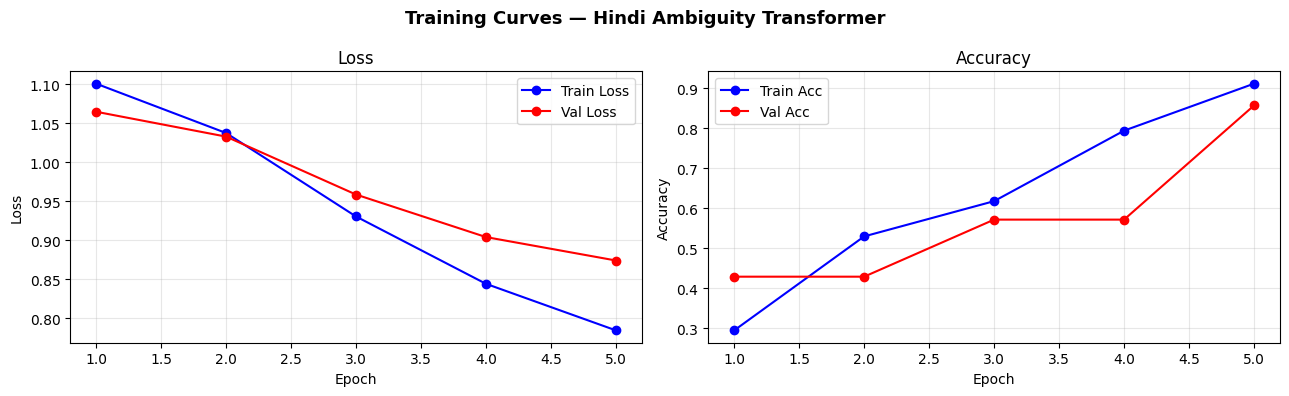

✅ Training curves saved.


In [15]:
epochs_range = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Training Curves — Hindi Ambiguity Transformer", fontsize=13, fontweight="bold")

axes[0].plot(epochs_range, history["train_loss"], "b-o", label="Train Loss")
axes[0].plot(epochs_range, history["val_loss"],   "r-o", label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history["train_acc"], "b-o", label="Train Acc")
axes[1].plot(epochs_range, history["val_acc"],   "r-o", label="Val Acc")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Training curves saved.")

In [16]:
# Load best weights
model.load_state_dict(torch.load("best_model.pt", map_location=DEVICE))
_, test_acc, test_preds, test_labels = eval_epoch(model, test_loader, DEVICE)

print(f"\n📋 Test Accuracy : {test_acc:.4f}\n")
print("Classification Report:")
print(
    classification_report(
        test_labels, test_preds,
        target_names=list(label_names.values()),
        zero_division=0,
    )
)


📋 Test Accuracy : 0.7500

Classification Report:
              precision    recall  f1-score   support

     Lexical       0.60      1.00      0.75         3
   Syntactic       1.00      0.33      0.50         3
    Semantic       1.00      1.00      1.00         2

    accuracy                           0.75         8
   macro avg       0.87      0.78      0.75         8
weighted avg       0.85      0.75      0.72         8



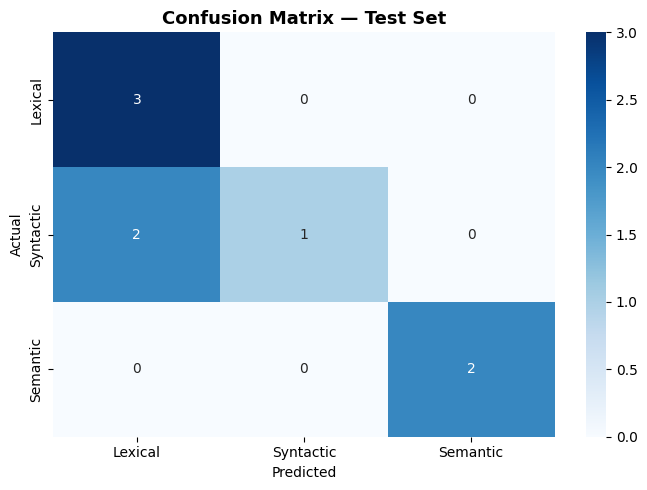

✅ Confusion matrix saved.


In [17]:
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=list(label_names.values()),
    yticklabels=list(label_names.values()),
)
plt.title("Confusion Matrix — Test Set", fontsize=13, fontweight="bold")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()
print("✅ Confusion matrix saved.")

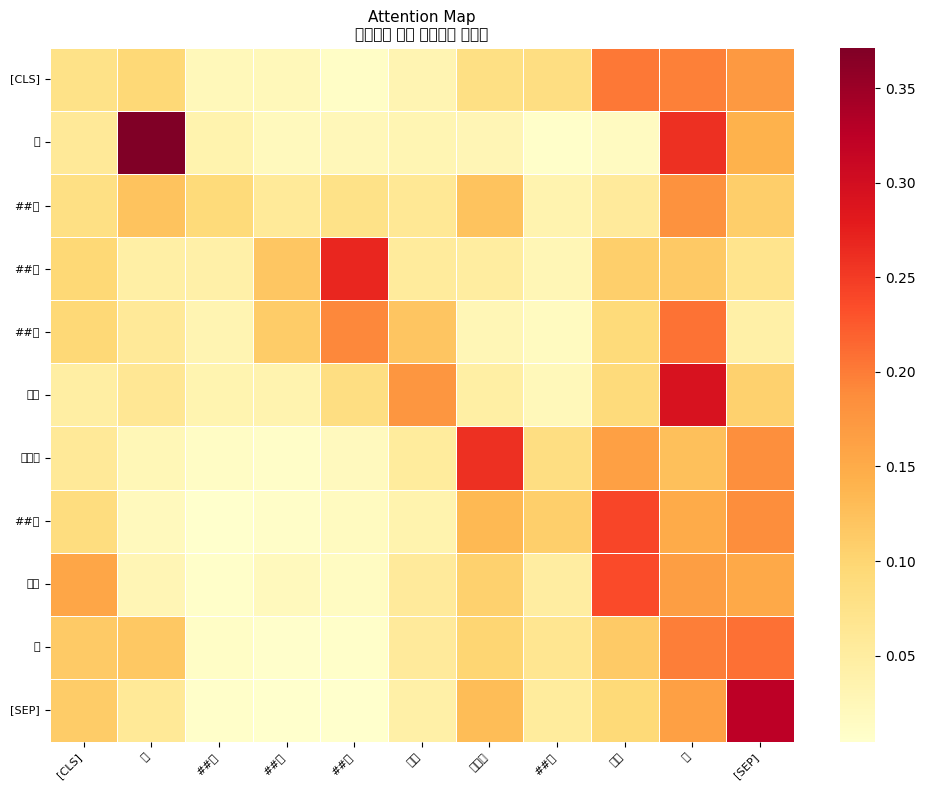

✅ Attention map saved.


In [20]:
def visualise_attention(sentence, tokenizer, model, device, layer=-1, head=0):
    """Plot attention weights of a single sentence."""
    model.eval()
    enc = tokenizer(
        sentence,
        return_tensors="pt",
        max_length=MAX_LENGTH,
        padding="max_length",
        truncation=True,
    )
    with torch.no_grad():
        outputs = model(
            input_ids=enc["input_ids"].to(device),
            attention_mask=enc["attention_mask"].to(device),
            output_attentions=True,
        )
    # attention shape: (batch, heads, seq, seq)
    attn   = outputs.attentions[layer][0, head].cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"][0])
    # trim padding
    n_real = int(enc["attention_mask"][0].sum().item())
    attn   = attn[:n_real, :n_real]
    tokens = tokens[:n_real]

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        attn, xticklabels=tokens, yticklabels=tokens,
        cmap="YlOrRd", linewidths=0.5,
    )
    plt.title(f"Attention Map\n{sentence}", fontsize=11)
    plt.xticks(rotation=45, ha="right", fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.savefig("attention_map.png", dpi=120, bbox_inches="tight")
    plt.show()

# Visualise on one lexical ambiguity sentence
visualise_attention("मुझे आम खाना है।", tokenizer, model, DEVICE)
print("✅ Attention map saved.")

In [21]:
def predict_ambiguity(sentences, tokenizer, model, device, max_len=128):
    model.eval()
    results = []
    for sentence in sentences:
        enc = tokenizer(
            sentence,
            return_tensors="pt",
            max_length=max_len,
            padding="max_length",
            truncation=True,
        )
        with torch.no_grad():
            logits = model(
                input_ids=enc["input_ids"].to(device),
                attention_mask=enc["attention_mask"].to(device),
            ).logits
        probs     = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
        pred_id   = int(np.argmax(probs))
        pred_name = label_names[pred_id]
        results.append(
            {
                "sentence":   sentence,
                "prediction": pred_name,
                "confidence": f"{probs[pred_id]*100:.1f}%",
                "Lexical":    f"{probs[0]*100:.1f}%",
                "Syntactic":  f"{probs[1]*100:.1f}%",
                "Semantic":   f"{probs[2]*100:.1f}%",
            }
        )
    return pd.DataFrame(results)


new_sentences = [
    "उसने कहा कि वह जाएगा।",         # Syntactic
    "हर छात्र कोई भाषा जानता है।",    # Semantic
    "यह बहुत काला है।",               # Lexical
    "वह आम आदमी है।",                 # Lexical (common/ordinary vs mango)
    "मैंने उसे मारते हुए देखा।",       # Syntactic
]

pred_df = predict_ambiguity(new_sentences, tokenizer, model, DEVICE)
print("\n🔮 Predictions on New Hindi Sentences:")
print(pred_df.to_string(index=False))


🔮 Predictions on New Hindi Sentences:
                   sentence prediction confidence Lexical Syntactic Semantic
      उसने कहा कि वह जाएगा।   Semantic      34.2%   32.5%     33.3%    34.2%
हर छात्र कोई भाषा जानता है।    Lexical      35.9%   35.9%     31.5%    32.6%
           यह बहुत काला है।   Semantic      34.9%   32.0%     33.2%    34.9%
             वह आम आदमी है।    Lexical      33.7%   33.7%     32.7%    33.6%
  मैंने उसे मारते हुए देखा।   Semantic      37.5%   30.7%     31.8%    37.5%


In [22]:
print("\n" + "="*60)
print("  ✅  HINDI NLP AMBIGUITY RESOLUTION — SUMMARY")
print("="*60)
print(f"  Model            : {MODEL_NAME}")
print(f"  Ambiguity types  : Lexical, Syntactic, Semantic")
print(f"  Dataset size     : {len(df)} sentences")
print(f"  Best Val Acc     : {best_val_acc:.4f}")
print(f"  Test Accuracy    : {test_acc:.4f}")
print(f"  Device           : {DEVICE}")
print("="*60)
print("""
Key Takeaways:
  • Ambiguity is a fundamental challenge in Hindi NLP.
  • mBERT effectively handles multilingual (Hindi) text.
  • Fine-tuning on domain-specific ambiguous data helps
    the model learn contextual disambiguation.
  • Attention maps reveal which tokens the model focuses
    on to resolve ambiguous meanings.
""")


  ✅  HINDI NLP AMBIGUITY RESOLUTION — SUMMARY
  Model            : bert-base-multilingual-cased
  Ambiguity types  : Lexical, Syntactic, Semantic
  Dataset size     : 49 sentences
  Best Val Acc     : 0.8571
  Test Accuracy    : 0.7500
  Device           : cpu

Key Takeaways:
  • Ambiguity is a fundamental challenge in Hindi NLP.
  • mBERT effectively handles multilingual (Hindi) text.
  • Fine-tuning on domain-specific ambiguous data helps
    the model learn contextual disambiguation.
  • Attention maps reveal which tokens the model focuses
    on to resolve ambiguous meanings.

